In [3]:
#Grab Data
import yfinance as yf

#Usual Suspects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [5]:
#Create a Portfolio
symbols = [
    'IDVY.MI',
    'IUKD.L',
    'IGCB.L',
    'SYBC.DE',
    'PST.MI',
    'ISP.MI',
    'NVDA',
    'MSFT',
    'TSM',
    'ENI.MI',
    'ENEL.MI',
    'XDWU.DE',
    'EUNL.DE',
    'VAGF.DE',
    'XAIX.DE'
]

In [7]:
#Get the stock data
data = yf.download(symbols, start="2019-01-01", auto_adjust=True)
#data2 = yf.download(symbols, start="2019-01-01")

#data.index = pd.to_datetime(data.index).tz_localize(None)
#data = data.reset_index()
if data is not None:
    data.to_csv('data/prices.csv', index=True)
   # data2.to_csv('data/prices2.csv', index=True)
else:
    print(f"No data , skipping CSV export.")

[*********************100%***********************]  15 of 15 completed


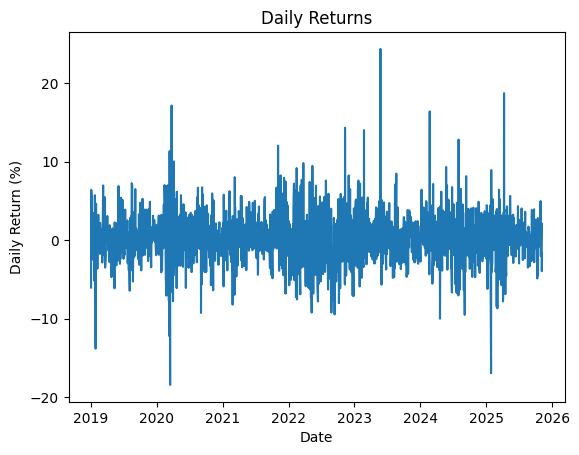

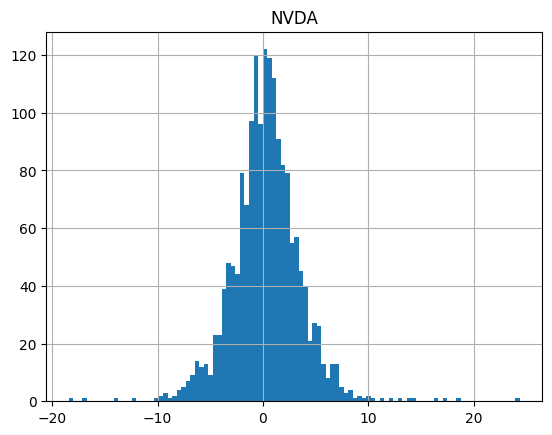

In [61]:
# Calculate daily returns
subset = data['Close'][[ 'NVDA']].dropna()
subset_daily_return = subset.pct_change() * 100
plt.plot(subset_daily_return)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.show()

subset_daily_return.hist(bins=100)
plt.show()

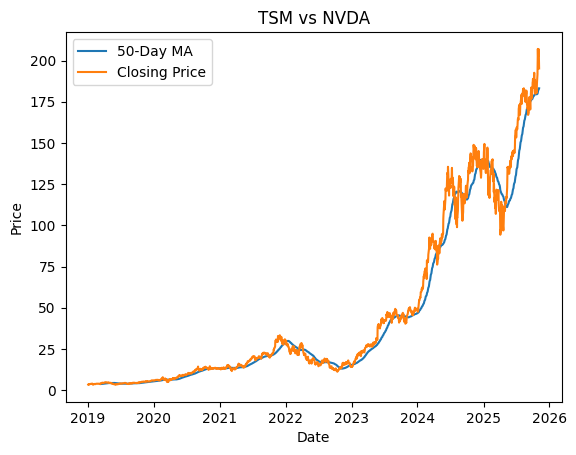

In [63]:
subset_mean= subset.rolling(window=50).mean()

plt.plot(subset_mean, label='50-Day MA')
plt.plot(subset, label='Closing Price')
plt.legend()
plt.title('TSM vs NVDA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()    

In [47]:
# Install TA-Lib if missing and import it

import talib as ta

# ensure we are working on a copy to avoid SettingWithCopyWarning
subset = subset.copy()

# Calculate technical indicators
subset['EMA_50'] = ta.EMA(subset['ENEL.MI'], timeperiod=50)
subset['EMA_200'] = ta.EMA(subset['ENEL.MI'], timeperiod=200)
print(subset.tail())


Ticker      ENEL.MI        NVDA    EMA_50   EMA_200
Date                                               
2025-10-29    8.710  207.039993  8.188795  7.564810
2025-10-30    8.796  202.889999  8.212607  7.577060
2025-10-31    8.772  202.490005  8.234544  7.588950
2025-11-03    8.814  206.880005  8.257267  7.601140
2025-11-04    8.957  198.690002  8.284708  7.614631


In [57]:
stocks = data.swaplevel(axis=1).sort_index(level=0)
stock = stocks['ENEL.MI'].dropna()

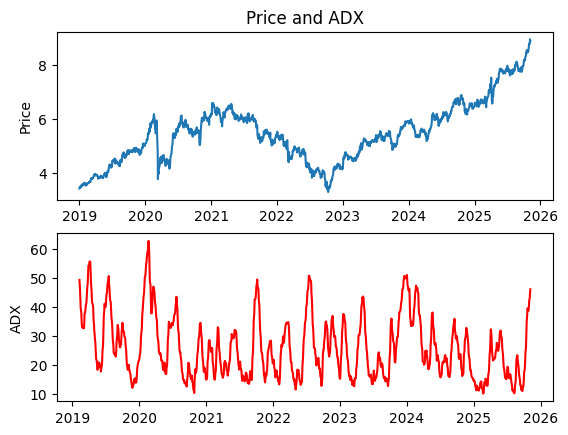

In [60]:
stock['ADX_14'] = ta.ADX(stock['High'],
                            stock['Low'], 
                            stock['Close'])
# Create subplots
fig, (ax1, ax2) = plt.subplots(2)

# Plot ADX with the price
ax1.set_ylabel('Price')
ax1.plot(stock['Close'])
ax2.set_ylabel('ADX')
ax2.plot(stock['ADX_14'], color='red')

ax1.set_title('Price and ADX')
plt.show()

In [41]:
import bt

# Define the strategy
bt_strategy = bt.Strategy('Trade_Weekly',
[bt.algos.RunWeekly(), # Run weekly
bt.algos.SelectAll(), # Use all data
bt.algos.WeighEqually(), # Maintain equal weights
bt.algos.Rebalance()]) # Rebalance

In [42]:
# Create a backtest
bt_test = bt.Backtest(bt_strategy, subset)
# Run the backtest
bt_res = bt.run(bt_test)

100%|██████████| 1/1 [00:00<00:00,  5.52it/s]


price  quantity
Date       Security                      
2019-01-02 ENEL.MI     3.419652  146213.0
           NVDA        3.377354  148044.0
2019-01-07 ENEL.MI     3.466737    2808.0
           NVDA        3.555371   -2738.0
2019-01-14 ENEL.MI     3.504404    2818.0
...                         ...       ...
2025-10-20 NVDA      182.639999    1052.0
2025-10-27 ENEL.MI     8.556000   19689.0
           NVDA      191.490005    -880.0
2025-11-03 ENEL.MI     8.814000   20694.0
           NVDA      206.880005    -882.0

[720 rows x 2 columns]

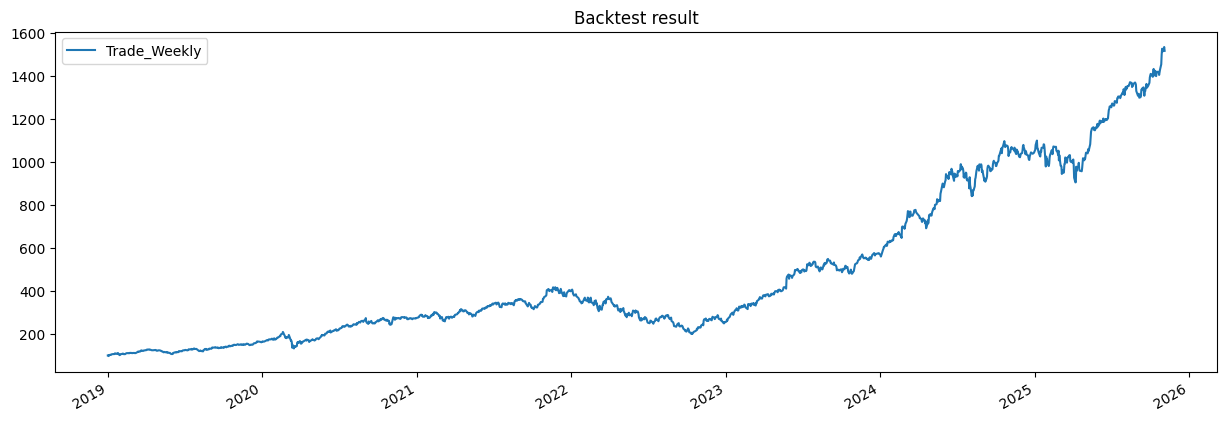

In [43]:
# Plot the result
bt_res.plot(title="Backtest result")

# Get trade details
bt_res.get_transactions()